In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [19]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cpu')
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.10.0+cu128


In [20]:
PATH="/kaggle/input/datasets/kandij/electric-production/Electric_Production.csv"

In [21]:
df=pd.read_csv(PATH)

In [22]:
df.head()

,DATE,Value
0,01-01-1985,72.5052
1,02-01-1985,70.6720
2,03-01-1985,62.4502
3,04-01-1985,57.4714
4,05-01-1985,55.3151


In [23]:
df.columns = ["DATE", "Production"]
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nLast 5 rows:")
print(df.tail())
print("\nData Types:\n", df.dtypes)
print("\nNull Values:\n", df.isnull().sum())
print("\nStatistics:\n", df["Production"].describe())

Shape: (397, 2)

First 5 rows:
        DATE  Production
0 1985-01-01     72.5052
1 1985-02-01     70.6720
2 1985-03-01     62.4502
3 1985-04-01     57.4714
4 1985-05-01     55.3151

Last 5 rows:
          DATE  Production
392 2017-09-01     98.6154
393 2017-10-01     93.6137
394 2017-11-01     97.3359
395 2017-12-01    114.7212
396 2018-01-01    129.4048

Data Types:
 DATE          datetime64[ns]
Production           float64
dtype: object

Null Values:
 DATE          0
Production    0
dtype: int64

Statistics:
 count    397.000000
mean      88.847218
std       15.387834
min       55.315100
25%       77.105200
50%       89.779500
75%      100.524400
max      129.404800
Name: Production, dtype: float64


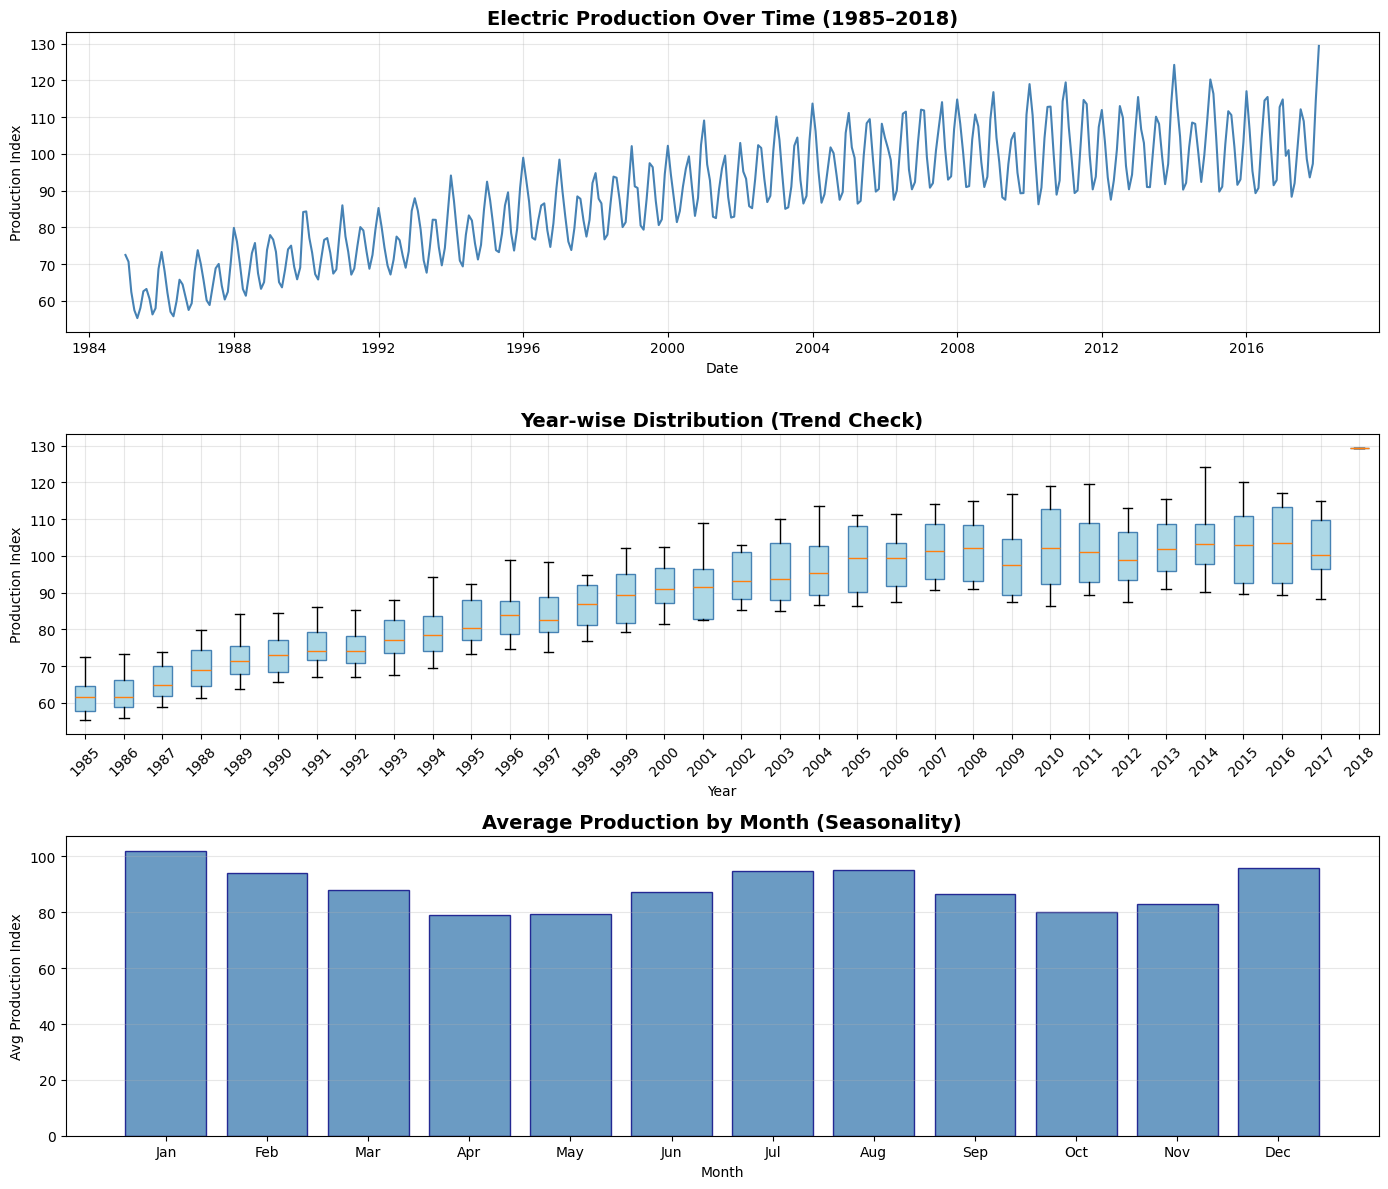

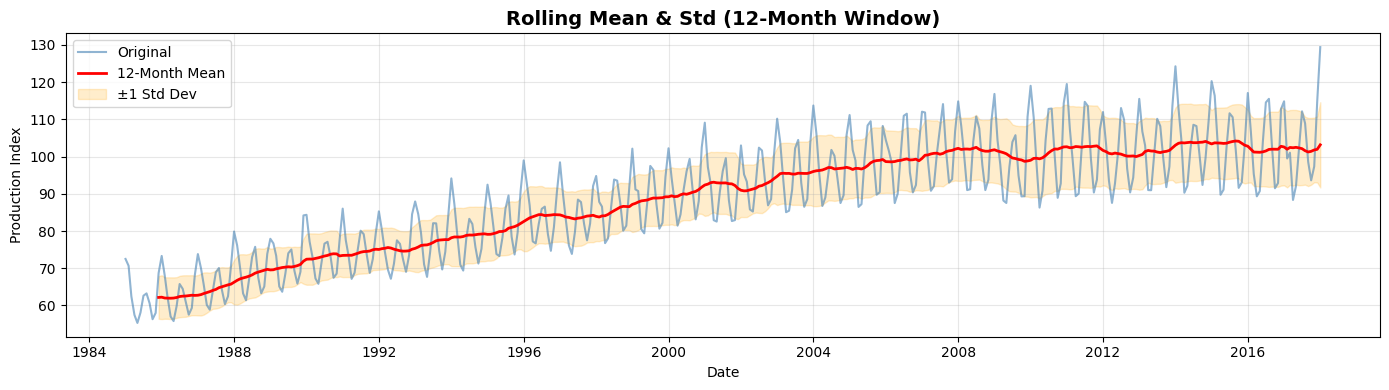

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# --- Plot 1: Full Time Series ---
axes[0].plot(df["DATE"], df["Production"], color="steelblue", linewidth=1.5)
axes[0].set_title("Electric Production Over Time (1985–2018)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Production Index")
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Year-wise Boxplot (Seasonality) ---
df["Year"]  = df["DATE"].dt.year
df["Month"] = df["DATE"].dt.month

yearly = [df[df["Year"] == y]["Production"].values for y in sorted(df["Year"].unique())]
axes[1].boxplot(yearly, labels=sorted(df["Year"].unique()), patch_artist=True,
                boxprops=dict(facecolor="lightblue", color="steelblue"))
axes[1].set_title("Year-wise Distribution (Trend Check)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Production Index")
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

# --- Plot 3: Monthly Seasonality ---
monthly_avg = df.groupby("Month")["Production"].mean()
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
axes[2].bar(month_names, monthly_avg.values, color="steelblue", edgecolor="navy", alpha=0.8)
axes[2].set_title("Average Production by Month (Seasonality)", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Avg Production Index")
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# --- Rolling Stats ---
df["Rolling_Mean_12"] = df["Production"].rolling(12).mean()
df["Rolling_Std_12"]  = df["Production"].rolling(12).std()

plt.figure(figsize=(14, 4))
plt.plot(df["DATE"], df["Production"],     label="Original",       color="steelblue", alpha=0.6)
plt.plot(df["DATE"], df["Rolling_Mean_12"],label="12-Month Mean",  color="red",       linewidth=2)
plt.fill_between(df["DATE"],
                 df["Rolling_Mean_12"] - df["Rolling_Std_12"],
                 df["Rolling_Mean_12"] + df["Rolling_Std_12"],
                 color="orange", alpha=0.2, label="±1 Std Dev")
plt.title("Rolling Mean & Std (12-Month Window)", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Production Index")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
data = df[["DATE", "Production"]].copy()
scaler = MinMaxScaler()
data["Production_scaled"] = scaler.fit_transform(data[["Production"]])

In [26]:
def create_sequences(series, seq_len):
    X, y = [], []
    for i in range(len(series) - seq_len):
        X.append(series[i : i + seq_len])
        y.append(series[i + seq_len])
    return np.array(X), np.array(y)

SEQ_LEN = 12
values = data["Production_scaled"].values
X, y   = create_sequences(values, SEQ_LEN)

In [27]:
n       = len(X)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_train, y_train = X[:n_train],           y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:],     y[n_train+n_val:]

print(f"Total sequences  : {n}")
print(f"Train sequences  : {len(X_train)}")
print(f"Val   sequences  : {len(X_val)}")
print(f"Test  sequences  : {len(X_test)}")
print(f"\nSequence length  : {SEQ_LEN} months")
print(f"Input shape      : {X_train.shape}  → (samples, timesteps)")
print(f"Target shape     : {y_train.shape} → (samples,)")

Total sequences  : 385
Train sequences  : 269
Val   sequences  : 57
Test  sequences  : 59

Sequence length  : 12 months
Input shape      : (269, 12)  → (samples, timesteps)
Target shape     : (269,) → (samples,)


In [28]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (samples, seq_len, 1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # (samples, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset   = TimeSeriesDataset(X_val,   y_val)
test_dataset  = TimeSeriesDataset(X_test,  y_test)

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

X_batch, y_batch = next(iter(train_loader))
print(f"Batch input shape  : {X_batch.shape}  → (batch, seq_len, features)")
print(f"Batch target shape : {y_batch.shape} → (batch, 1)")
print(f"\nTrain batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

Batch input shape  : torch.Size([16, 12, 1])  → (batch, seq_len, features)
Batch target shape : torch.Size([16, 1]) → (batch, 1)

Train batches : 17
Val   batches : 4
Test  batches : 4


In [29]:
# Cell 6: RNN Model

class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout,
            batch_first = True
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.rnn(x)       # out: (batch, seq_len, hidden_size)
        out    = out[:, -1, :]     # take last timestep → (batch, hidden_size)
        out    = self.fc(out)      # → (batch, 1)
        return out

# --- Training Function ---
def train_model(model, train_loader, val_loader, epochs=100, lr=0.001):
    model     = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_weights  = None

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        # --- Validate ---
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                preds    = model(X_batch)
                val_loss += criterion(preds, y_batch).item()

        train_loss /= len(train_loader)
        val_loss   /= len(val_loader)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        # Save best weights
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1:3d}/{epochs}]  Train Loss: {train_loss:.6f}  Val Loss: {val_loss:.6f}")

    model.load_state_dict(best_weights)
    return model, train_losses, val_losses

# --- Evaluation Function ---
def evaluate_model(model, loader):
    model.eval()
    preds_all, true_all = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            preds   = model(X_batch).cpu().numpy()
            preds_all.append(preds)
            true_all.append(y_batch.numpy())

    preds_all = np.concatenate(preds_all).reshape(-1, 1)
    true_all  = np.concatenate(true_all).reshape(-1, 1)

    # Inverse transform
    preds_inv = scaler.inverse_transform(preds_all).flatten()
    true_inv  = scaler.inverse_transform(true_all).flatten()

    mae  = mean_absolute_error(true_inv, preds_inv)
    rmse = np.sqrt(mean_squared_error(true_inv, preds_inv))
    mape = np.mean(np.abs((true_inv - preds_inv) / true_inv)) * 100
    r2   = r2_score(true_inv, preds_inv)

    return preds_inv, true_inv, {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}

# --- Train RNN ---
print("=" * 45)
print("           Training RNN Model")
print("=" * 45)
rnn_model = RNNModel(input_size=1, hidden_size=64, num_layers=2, dropout=0.2)
print(f"Parameters: {sum(p.numel() for p in rnn_model.parameters()):,}\n")
rnn_model, rnn_train_losses, rnn_val_losses = train_model(rnn_model, train_loader, val_loader, epochs=100)

# --- Evaluate RNN ---
rnn_preds, rnn_true, rnn_metrics = evaluate_model(rnn_model, test_loader)
print(f"\n📊 RNN Test Results:")
print(f"   MAE  : {rnn_metrics['MAE']:.4f}")
print(f"   RMSE : {rnn_metrics['RMSE']:.4f}")
print(f"   MAPE : {rnn_metrics['MAPE']:.2f}%")
print(f"   R²   : {rnn_metrics['R2']:.4f}")

           Training RNN Model
Parameters: 14,721

Epoch [ 20/100]  Train Loss: 0.042739  Val Loss: 0.052584
Epoch [ 40/100]  Train Loss: 0.008947  Val Loss: 0.004190
Epoch [ 60/100]  Train Loss: 0.002962  Val Loss: 0.003679
Epoch [ 80/100]  Train Loss: 0.002103  Val Loss: 0.002178
Epoch [100/100]  Train Loss: 0.002036  Val Loss: 0.002323

📊 RNN Test Results:
   MAE  : 3.0235
   RMSE : 4.4279
   MAPE : 2.84%
   R²   : 0.7966


In [30]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout,
            batch_first = True
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out    = out[:, -1, :]
        out    = self.fc(out)
        return out

print("=" * 45)
print("           Training LSTM Model")
print("=" * 45)
lstm_model = LSTMModel(input_size=1, hidden_size=64, num_layers=2, dropout=0.2)
print(f"Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}\n")
lstm_model, lstm_train_losses, lstm_val_losses = train_model(lstm_model, train_loader, val_loader, epochs=100)

lstm_preds, lstm_true, lstm_metrics = evaluate_model(lstm_model, test_loader)
print(f"\n📊 LSTM Test Results:")
print(f"   MAE  : {lstm_metrics['MAE']:.4f}")
print(f"   RMSE : {lstm_metrics['RMSE']:.4f}")
print(f"   MAPE : {lstm_metrics['MAPE']:.2f}%")
print(f"   R²   : {lstm_metrics['R2']:.4f}")

           Training LSTM Model
Parameters: 52,545

Epoch [ 20/100]  Train Loss: 0.010594  Val Loss: 0.015020
Epoch [ 40/100]  Train Loss: 0.008406  Val Loss: 0.015418
Epoch [ 60/100]  Train Loss: 0.008152  Val Loss: 0.015129
Epoch [ 80/100]  Train Loss: 0.008304  Val Loss: 0.015143
Epoch [100/100]  Train Loss: 0.007925  Val Loss: 0.015100

📊 LSTM Test Results:
   MAE  : 8.0606
   RMSE : 9.5506
   MAPE : 7.95%
   R²   : 0.0537


In [31]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout,
            batch_first = True
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.gru(x)
        out    = out[:, -1, :]
        out    = self.fc(out)
        return out

print("=" * 45)
print("           Training GRU Model")
print("=" * 45)
gru_model = GRUModel(input_size=1, hidden_size=64, num_layers=2, dropout=0.2)
print(f"Parameters: {sum(p.numel() for p in gru_model.parameters()):,}\n")
gru_model, gru_train_losses, gru_val_losses = train_model(gru_model, train_loader, val_loader, epochs=100)

gru_preds, gru_true, gru_metrics = evaluate_model(gru_model, test_loader)
print(f"\n📊 GRU Test Results:")
print(f"   MAE  : {gru_metrics['MAE']:.4f}")
print(f"   RMSE : {gru_metrics['RMSE']:.4f}")
print(f"   MAPE : {gru_metrics['MAPE']:.2f}%")
print(f"   R²   : {gru_metrics['R2']:.4f}")

           Training GRU Model
Parameters: 39,937

Epoch [ 20/100]  Train Loss: 0.008667  Val Loss: 0.014657
Epoch [ 40/100]  Train Loss: 0.020807  Val Loss: 0.018661
Epoch [ 60/100]  Train Loss: 0.007987  Val Loss: 0.010255
Epoch [ 80/100]  Train Loss: 0.004767  Val Loss: 0.006037
Epoch [100/100]  Train Loss: 0.005253  Val Loss: 0.003503

📊 GRU Test Results:
   MAE  : 3.6874
   RMSE : 4.9915
   MAPE : 3.47%
   R²   : 0.7415


In [32]:
class PatchEmbedding(nn.Module):
    def __init__(self, patch_size, d_model):
        super().__init__()
        self.patch_size = patch_size
        self.projection = nn.Linear(patch_size, d_model)

    def forward(self, x):
        B, T, C    = x.shape
        num_patches = T // self.patch_size
        x = x[:, :num_patches * self.patch_size, :]
        x = x.reshape(B, num_patches, self.patch_size * C)
        x = self.projection(x)
        return x

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class PatchTST(nn.Module):
    def __init__(self, seq_len=12, patch_size=4, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        self.patch_embed = PatchEmbedding(patch_size, d_model)
        self.pos_enc     = PositionalEncoding(d_model)
        encoder_layer    = nn.TransformerEncoderLayer(
            d_model    = d_model,
            nhead      = nhead,
            dim_feedforward = d_model * 4,
            dropout    = dropout,
            batch_first = True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        num_patches      = seq_len // patch_size
        self.fc          = nn.Sequential(
            nn.Linear(d_model * num_patches, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.pos_enc(x)
        x = self.transformer(x)
        x = x.reshape(x.size(0), -1)
        x = self.fc(x)
        return x

import math

print("=" * 45)
print("      Training Vision Transformer Model")
print("=" * 45)
vit_model = PatchTST(seq_len=SEQ_LEN, patch_size=4, d_model=64, nhead=4, num_layers=2, dropout=0.2)
print(f"Parameters: {sum(p.numel() for p in vit_model.parameters()):,}\n")
vit_model, vit_train_losses, vit_val_losses = train_model(vit_model, train_loader, val_loader, epochs=100)

vit_preds, vit_true, vit_metrics = evaluate_model(vit_model, test_loader)
print(f"\n📊 Vision Transformer Test Results:")
print(f"   MAE  : {vit_metrics['MAE']:.4f}")
print(f"   RMSE : {vit_metrics['RMSE']:.4f}")
print(f"   MAPE : {vit_metrics['MAPE']:.2f}%")
print(f"   R²   : {vit_metrics['R2']:.4f}")

      Training Vision Transformer Model
Parameters: 112,705

Epoch [ 20/100]  Train Loss: 0.014506  Val Loss: 0.003743
Epoch [ 40/100]  Train Loss: 0.002316  Val Loss: 0.003008
Epoch [ 60/100]  Train Loss: 0.001414  Val Loss: 0.002699
Epoch [ 80/100]  Train Loss: 0.001429  Val Loss: 0.002735
Epoch [100/100]  Train Loss: 0.001518  Val Loss: 0.002639

📊 Vision Transformer Test Results:
   MAE  : 2.9292
   RMSE : 4.2748
   MAPE : 2.73%
   R²   : 0.8104


In [33]:
results = pd.DataFrame({
    "Model" : ["RNN", "LSTM", "GRU", "Vision Transformer"],
    "MAE"   : [rnn_metrics["MAE"],  lstm_metrics["MAE"],  gru_metrics["MAE"],  vit_metrics["MAE"]],
    "RMSE"  : [rnn_metrics["RMSE"], lstm_metrics["RMSE"], gru_metrics["RMSE"], vit_metrics["RMSE"]],
    "MAPE"  : [rnn_metrics["MAPE"], lstm_metrics["MAPE"], gru_metrics["MAPE"], vit_metrics["MAPE"]],
    "R2"    : [rnn_metrics["R2"],   lstm_metrics["R2"],   gru_metrics["R2"],   vit_metrics["R2"]]
})

results["MAE"]  = results["MAE"].round(4)
results["RMSE"] = results["RMSE"].round(4)
results["MAPE"] = results["MAPE"].round(2)
results["R2"]   = results["R2"].round(4)

print("=" * 60)
print("              MODEL COMPARISON RESULTS")
print("=" * 60)
print(results.to_string(index=False))
print("=" * 60)
print(f"\n🏆 Best MAE  : {results.loc[results['MAE'].idxmin(),  'Model']}")
print(f"🏆 Best RMSE : {results.loc[results['RMSE'].idxmin(), 'Model']}")
print(f"🏆 Best MAPE : {results.loc[results['MAPE'].idxmin(), 'Model']}")
print(f"🏆 Best R²   : {results.loc[results['R2'].idxmax(),   'Model']}")

              MODEL COMPARISON RESULTS
             Model    MAE   RMSE  MAPE     R2
               RNN 3.0235 4.4279  2.84 0.7966
              LSTM 8.0606 9.5506  7.95 0.0537
               GRU 3.6874 4.9915  3.47 0.7415
Vision Transformer 2.9292 4.2748  2.73 0.8104

🏆 Best MAE  : Vision Transformer
🏆 Best RMSE : Vision Transformer
🏆 Best MAPE : Vision Transformer
🏆 Best R²   : Vision Transformer


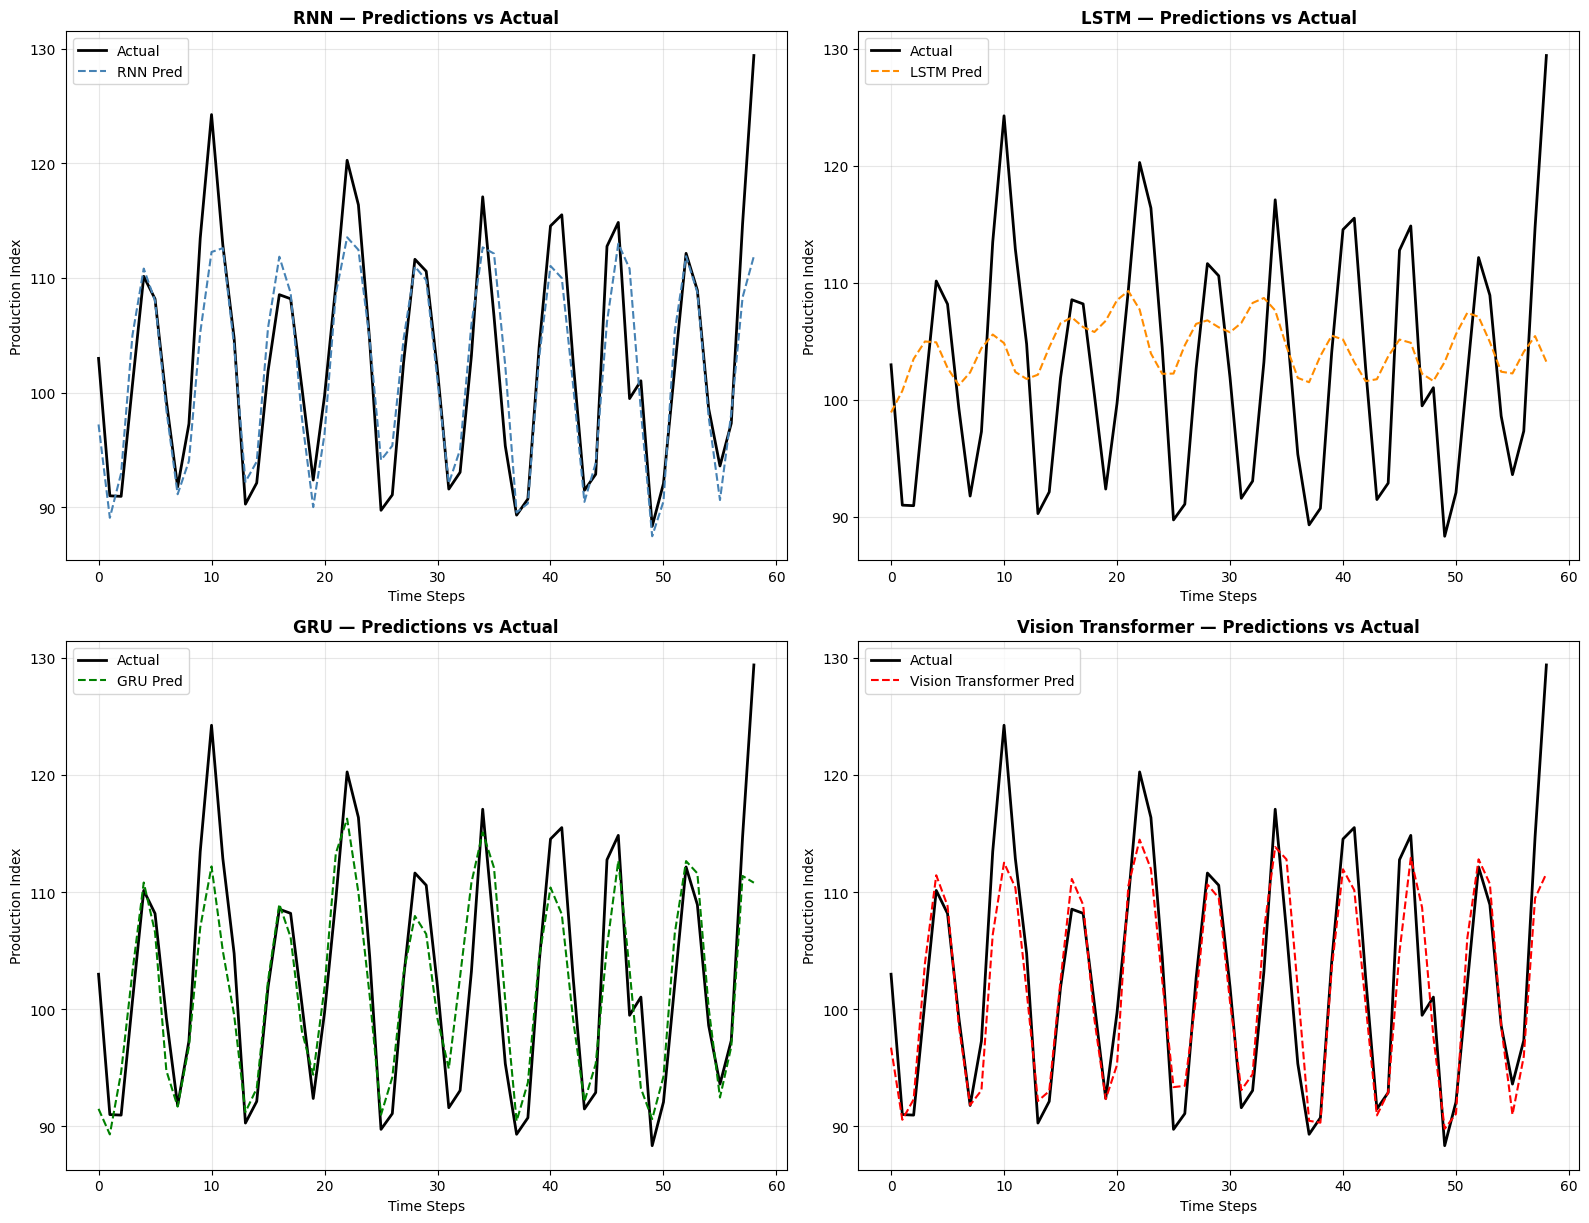

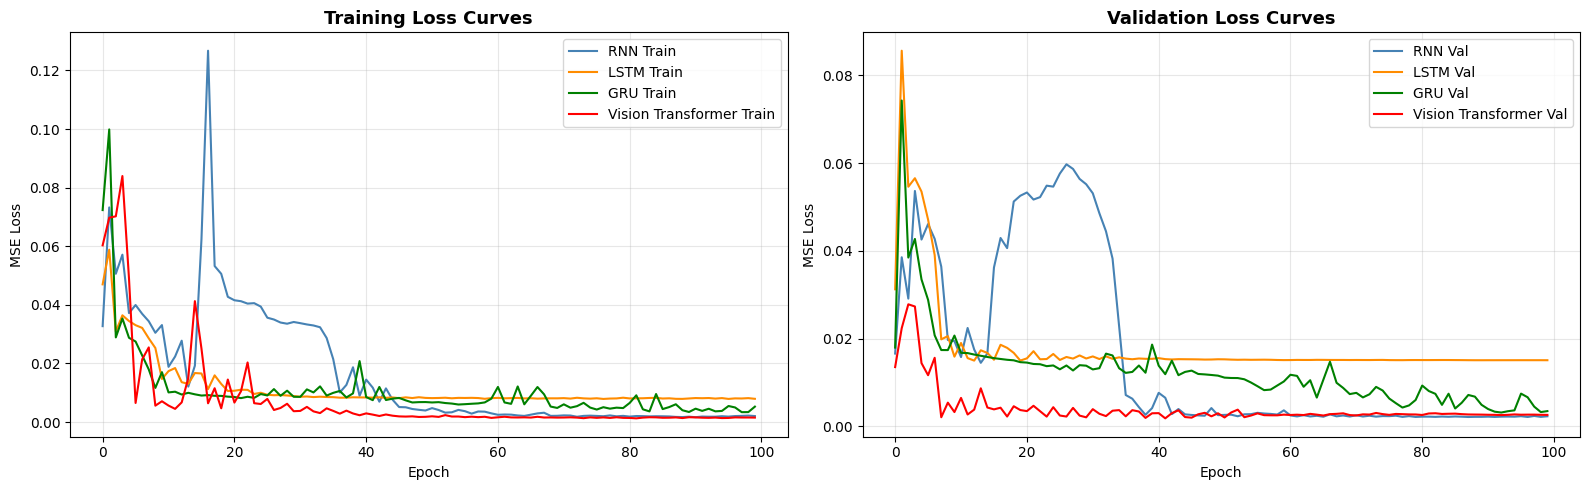

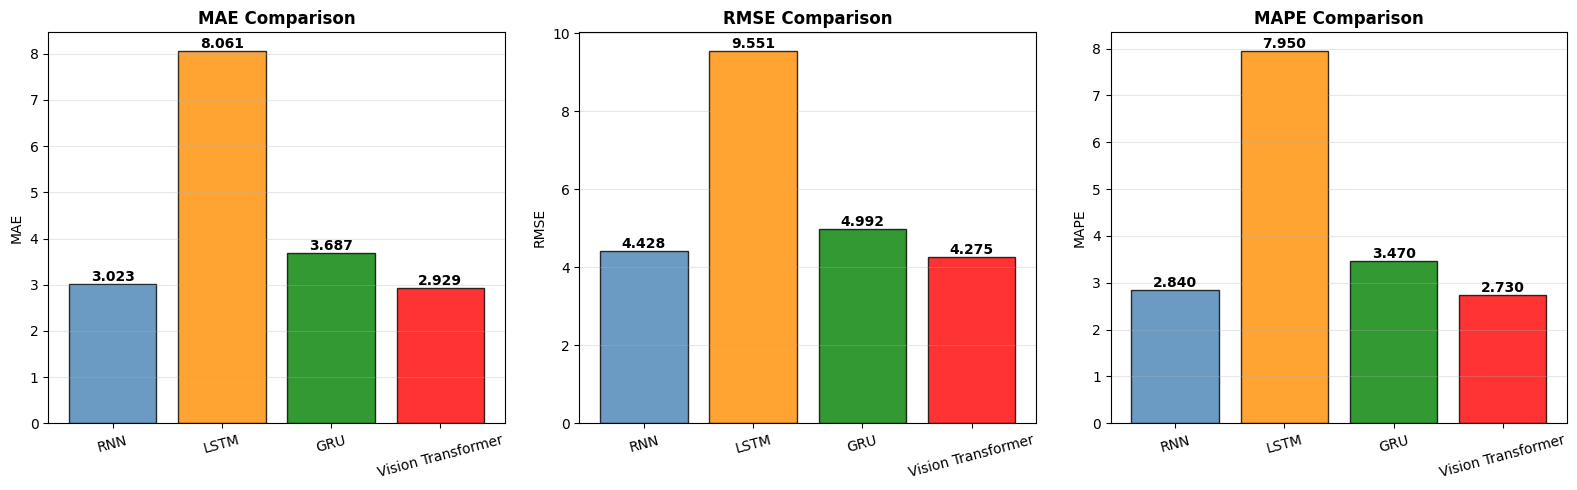

In [34]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

models      = ["RNN", "LSTM", "GRU", "Vision Transformer"]
all_preds   = [rnn_preds,  lstm_preds,  gru_preds,  vit_preds]
train_losses_all = [rnn_train_losses, lstm_train_losses, gru_train_losses, vit_train_losses]
val_losses_all   = [rnn_val_losses,   lstm_val_losses,   gru_val_losses,   vit_val_losses]
colors      = ["steelblue", "darkorange", "green", "red"]

for i, (name, preds, color) in enumerate(zip(models, all_preds, colors)):
    row, col = divmod(i, 2)
    axes[row, col].plot(rnn_true,  label="Actual",      color="black",  linewidth=2)
    axes[row, col].plot(preds,     label=f"{name} Pred", color=color, linewidth=1.5, linestyle="--")
    axes[row, col].set_title(f"{name} — Predictions vs Actual", fontsize=12, fontweight="bold")
    axes[row, col].set_xlabel("Time Steps")
    axes[row, col].set_ylabel("Production Index")
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

axes[2, 0].set_visible(False)
axes[2, 1].set_visible(False)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for name, tl, vl, color in zip(models, train_losses_all, val_losses_all, colors):
    axes[0].plot(tl, label=f"{name} Train", color=color, linewidth=1.5)
    axes[1].plot(vl, label=f"{name} Val",   color=color, linewidth=1.5)

axes[0].set_title("Training Loss Curves",   fontsize=13, fontweight="bold")
axes[1].set_title("Validation Loss Curves", fontsize=13, fontweight="bold")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

metrics_to_plot = ["MAE", "RMSE", "MAPE"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, metric in enumerate(metrics_to_plot):
    bars = axes[i].bar(results["Model"], results[metric], color=colors, edgecolor="black", alpha=0.8)
    axes[i].set_title(f"{metric} Comparison", fontsize=12, fontweight="bold")
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, results[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                     f"{val:.3f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()